In [ ]:
!pip install batchgenerators
!git clone https://github.com/mohammadnabia/DA_nnUNet.git
%cd DA_nnUNet
!pip install -e .


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 4.3 MB/s eta 0:00:00
  Created wheel for batchgenerators: filename=batchgenerators-0.25.1-py3-none-any.whl size=93088 sha256=c9416f05bd4d3ff6d79a595718bdfbb3eec5bcc3ec8e8e125d25d1660f8c91a5
  Stored in directory: /root/.cache/pip/wheels/56/11/c7/fadca30e054c602093ffe36ba8a2f0a87dd2f86ac75191d3ed
Successfully built batchgenerators


Cloning into 'DA_nnUNet'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (270/270), done.
remote: Total 297 (delta 41), reused 267 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (297/297), 2.58 MiB | 8.12 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/DA_nnUNet
Obtaining file:///content/DA_nnUNet
  Installing build dependencies ... canceled
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 377, in run
^C


Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


ground truth (labelsTs)

In [ ]:
!ls /content/drive/MyDrive

'0_testing nnunet pretrained on brats .ipynb'
 1_DA_nnUNet_4Scenarios_Prediction_and_Export.ipynb
 2_DA_nnUNet_Results_Analysis.ipynb
 3_Step1_Baseline_nnUNet_inference_and_Evaluation_on_peds.ipynb
 4_Step2_nnUNet_Baseline_Evaluation_BraTSPEDs2023.ipynb
 BraTS-peds2023
'Colab Notebooks'
 DA_nnUNet_Results
 nnunet10Ptest
 nnUNet_Baseline_Results


In [ ]:
!unzip -q "/content/drive/MyDrive/BraTS-peds2023/BraTS-PEDs-2023.zip" -d /content/BraTS_PEDs_2023

In [ ]:
import os
import shutil
import glob

source_dir = "/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData"
labels_dir = "/content/labelsTs"
os.makedirs(labels_dir, exist_ok=True)

cases = sorted(os.listdir(source_dir))
for case in cases:
    case_path = os.path.join(source_dir, case)
    if not os.path.isdir(case_path):
        continue
    seg_file = glob.glob(os.path.join(case_path, "*seg.nii.gz"))
    if len(seg_file) == 1:
        shutil.copy(seg_file[0], os.path.join(labels_dir, f"{case}.nii.gz"))
    else:
        print(f"Segmentation missing for case: {case}")


In [ ]:
import os

predictions_dir = "/content/drive/MyDrive/nnUNet_Baseline_Results/no_TTA"
labels_dir = "/content/labelsTs"


In [ ]:
import glob

pred_files = sorted(glob.glob(os.path.join(predictions_dir, "*.nii.gz")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))

print(f"تعداد پیش‌بینی‌ها: {len(pred_files)}")
print(f"تعداد ground truth ها: {len(label_files)}")


تعداد پیش‌بینی‌ها: 99
تعداد ground truth ها: 99


In [ ]:
!pip install SimpleITK


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.6 MB/s eta 0:00:00


In [ ]:
import SimpleITK as sitk
import numpy as np
import pandas as pd

def compute_metrics(pred_path, gt_path):
    pred = sitk.ReadImage(pred_path)
    gt = sitk.ReadImage(gt_path)

    pred = sitk.Cast(pred, sitk.sitkUInt8)
    gt = sitk.Cast(gt, sitk.sitkUInt8)

    dice_filter = sitk.LabelOverlapMeasuresImageFilter()
    dice_filter.Execute(pred, gt)
    dice_score = dice_filter.GetDiceCoefficient()

    hausdorff_filter = sitk.HausdorffDistanceImageFilter()
    hausdorff_filter.Execute(pred, gt)
    hausdorff_distance = hausdorff_filter.GetHausdorffDistance()

    return dice_score, hausdorff_distance


In [ ]:
results = []
for pred_path in pred_files:
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")
    gt_path = os.path.join(labels_dir, f"{case_id}.nii.gz")
    if not os.path.exists(gt_path):
        print(f"Ground truth not found for {case_id}")
        continue
    dice, hausdorff = compute_metrics(pred_path, gt_path)
    results.append({"case_id": case_id, "dice": dice, "hausdorff": hausdorff})

df_results = pd.DataFrame(results)
print(df_results)


                case_id      dice  hausdorff
0   BraTS-PED-00002-000  0.842770  16.309506
1   BraTS-PED-00003-000  0.745491  85.621259
2   BraTS-PED-00004-000  0.160098  47.895720
3   BraTS-PED-00006-000  0.673845  22.045408
4   BraTS-PED-00008-000  0.341765   5.000000
..                  ...       ...        ...
94  BraTS-PED-00142-000  0.216092  36.959437
95  BraTS-PED-00143-000  0.468460  10.630146
96  BraTS-PED-00167-000  0.429428  11.357817
97  BraTS-PED-00170-000  0.534963  37.376463
98  BraTS-PED-00171-000  0.821153  41.279535

[99 rows x 3 columns]


In [ ]:
df_results.to_csv("/content/drive/MyDrive/nnUNet_Baseline_Results/no_TTA/evaluation_results.csv", index=False)


2️⃣ محاسبه میانگین و انحراف معیار


In [ ]:
dice_mean = df_results['dice'].mean()
dice_std = df_results['dice'].std()
hausdorff_mean = df_results['hausdorff'].mean()
hausdorff_std = df_results['hausdorff'].std()

print(f"Mean Dice: {dice_mean:.4f} ± {dice_std:.4f}")
print(f"Mean Hausdorff: {hausdorff_mean:.4f} ± {hausdorff_std:.4f}")


Mean Dice: 0.5884 ± 0.2496
Mean Hausdorff: 27.7252 ± 23.2036


boxplot

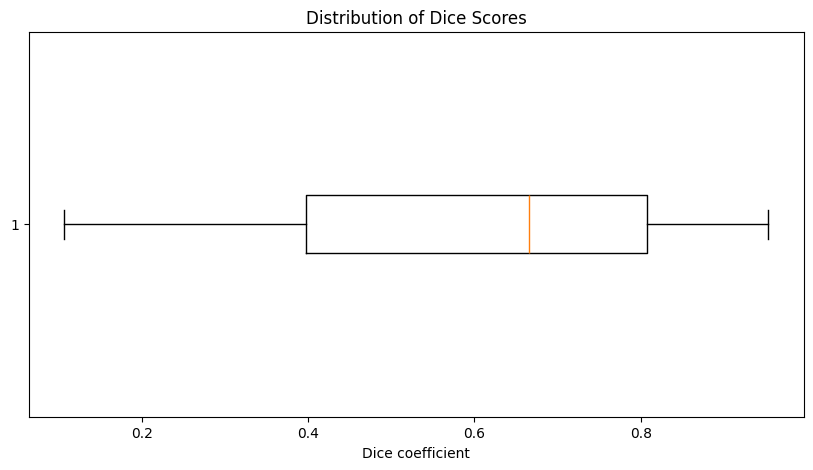

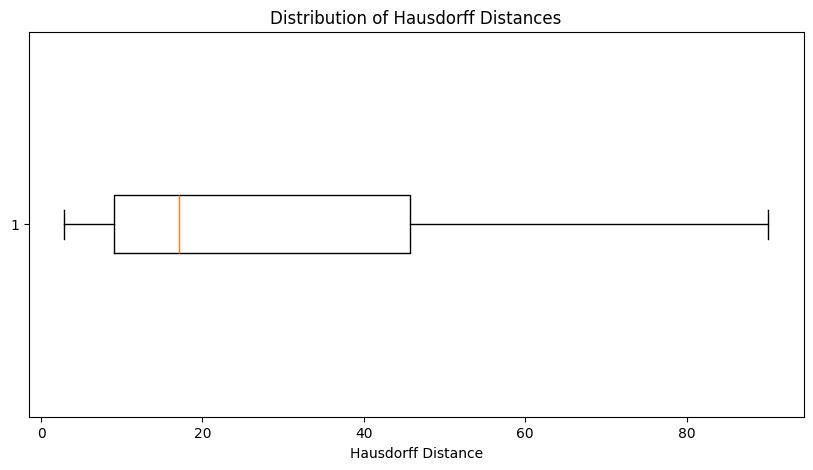

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.boxplot(df_results['dice'], vert=False)
plt.xlabel("Dice coefficient")
plt.title("Distribution of Dice Scores")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(df_results['hausdorff'], vert=False)
plt.xlabel("Hausdorff Distance")
plt.title("Distribution of Hausdorff Distances")
plt.show()


بررسی کیس‌هایی با دایس پایین (خطای زیاد)

In [ ]:
low_dice_cases = df_results[df_results['dice'] < 0.5]
print("Cases with Dice < 0.5:")
print(low_dice_cases)


Cases with Dice < 0.5:
                case_id      dice  hausdorff
2   BraTS-PED-00004-000  0.160098  47.895720
4   BraTS-PED-00008-000  0.341765   5.000000
7   BraTS-PED-00019-000  0.229953  22.583180
11  BraTS-PED-00024-000  0.106044  67.786429
12  BraTS-PED-00025-000  0.223616   9.000000
13  BraTS-PED-00026-000  0.129779  64.007812
14  BraTS-PED-00032-000  0.333355  45.814845
15  BraTS-PED-00036-000  0.172675   5.000000
18  BraTS-PED-00040-000  0.137678  24.758837
20  BraTS-PED-00042-000  0.216521  49.295030
21  BraTS-PED-00044-000  0.361617  24.413111
23  BraTS-PED-00047-000  0.478114  47.391982
24  BraTS-PED-00048-000  0.165945  10.677078
32  BraTS-PED-00062-000  0.216207   7.000000
39  BraTS-PED-00078-000  0.126277  56.780278
40  BraTS-PED-00079-000  0.434271  53.600373
43  BraTS-PED-00082-000  0.267873  50.139805
46  BraTS-PED-00085-000  0.483236  57.008771
47  BraTS-PED-00086-000  0.403501  70.943640
51  BraTS-PED-00098-000  0.327520   5.385165
59  BraTS-PED-00106-000  0.25935

ررسی multi-class بودن segmentation

In [ ]:
import SimpleITK as sitk
import numpy as np

# یک کیس رو به صورت تست انتخاب کن
example_case = '/content/drive/MyDrive/nnUNet_Baseline_Results/no_TTA/BraTS-PED-00002-000.nii.gz'

# بارگذاری segmentation
pred = sitk.ReadImage(example_case)
pred_array = sitk.GetArrayFromImage(pred)

# کلاس‌های موجود
unique_labels = np.unique(pred_array)
print(f"Unique labels in segmentation: {unique_labels}")


Unique labels in segmentation: [0 1 2 3]


In [ ]:
import json

with open('/content/drive/MyDrive/nnUNet_Baseline_Results/no_TTA/dataset.json', 'r') as f:
    dataset_info = json.load(f)

print(json.dumps(dataset_info, indent=4))


{
    "channel_names": {
        "0": "T1",
        "1": "T1ce",
        "2": "T2",
        "3": "Flair"
    },
    "labels": {
        "background": 0,
        "whole tumor": [
            1,
            2,
            3
        ],
        "tumor core": [
            2,
            3
        ],
        "enhancing tumor": [
            3
        ]
    },
    "numTraining": 1251,
    "file_ending": ".nii.gz",
    "reference": "see https://www.synapse.org/#!Synapse:syn25829067/wiki/610863",
    "licence": "see https://www.synapse.org/#!Synapse:syn25829067/wiki/610863",
    "regions_class_order": [
        1,
        2,
        3
    ],
    "dataset_release": "1.0"
}


In [ ]:
def create_combined_labels(pred_array, label_list):
    combined = np.isin(pred_array, label_list).astype(np.uint8)
    return combined


In [ ]:
def compute_region_metrics(pred, gt, region_name, region_labels):
    pred_combined = create_combined_labels(pred, region_labels)
    gt_combined = create_combined_labels(gt, region_labels)

    intersection = np.sum(pred_combined * gt_combined)
    union = np.sum(pred_combined) + np.sum(gt_combined)
    dice = (2.0 * intersection) / union if union > 0 else np.nan

    # بررسی خالی بودن segmentation predicted و ground truth
    if np.sum(pred_combined) == 0 or np.sum(gt_combined) == 0:
        hausdorff = np.nan  # چون Hausdorff قابل محاسبه نیست
    else:
        pred_sitk = sitk.GetImageFromArray(pred_combined)
        gt_sitk = sitk.GetImageFromArray(gt_combined)
        hausdorff_filter = sitk.HausdorffDistanceImageFilter()
        hausdorff_filter.Execute(pred_sitk, gt_sitk)
        hausdorff = hausdorff_filter.GetHausdorffDistance()

    return dice, hausdorff


In [ ]:
results = []
for pred_path in pred_files:
    case_id = os.path.basename(pred_path).replace(".nii.gz", "")
    gt_path = os.path.join(labels_dir, f"{case_id}.nii.gz")
    if not os.path.exists(gt_path):
        continue

    pred = sitk.ReadImage(pred_path)
    gt = sitk.ReadImage(gt_path)
    pred_array = sitk.GetArrayFromImage(pred)
    gt_array = sitk.GetArrayFromImage(gt)

    dice_wt, hausdorff_wt = compute_region_metrics(pred_array, gt_array, 'WT', [1,2,3])
    dice_tc, hausdorff_tc = compute_region_metrics(pred_array, gt_array, 'TC', [2,3])
    dice_et, hausdorff_et = compute_region_metrics(pred_array, gt_array, 'ET', [3])

    results.append({
        "case_id": case_id,
        "dice_WT": dice_wt,
        "hausdorff_WT": hausdorff_wt,
        "dice_TC": dice_tc,
        "hausdorff_TC": hausdorff_tc,
        "dice_ET": dice_et,
        "hausdorff_ET": hausdorff_et
    })

df_results = pd.DataFrame(results)
print(df_results)


                case_id   dice_WT  hausdorff_WT   dice_TC  hausdorff_TC  \
0   BraTS-PED-00002-000  0.912751     16.309506  0.768844     12.409674   
1   BraTS-PED-00003-000  0.899670     85.621259  0.861199     88.729927   
2   BraTS-PED-00004-000  0.936573     47.895720  0.259792     42.614552   
3   BraTS-PED-00006-000  0.894679     22.045408  0.824258      7.000000   
4   BraTS-PED-00008-000  0.887693      5.000000  0.042110     26.720778   
..                  ...       ...           ...       ...           ...   
94  BraTS-PED-00142-000  0.798340     36.959437  0.000000     61.595454   
95  BraTS-PED-00143-000  0.905942     10.630146  0.462471     20.542639   
96  BraTS-PED-00167-000  0.876158     11.357817  0.128488     23.280893   
97  BraTS-PED-00170-000  0.760690     37.376463  0.264567     32.787193   
98  BraTS-PED-00171-000  0.821153     41.279535       NaN           NaN   

     dice_ET  hausdorff_ET  
0   0.763959      5.000000  
1   0.909213     88.729927  
2   0.323353

In [ ]:
print("Mean Dice:")
print(df_results[['dice_WT', 'dice_TC', 'dice_ET']].mean())
print("\nMean Hausdorff:")
print(df_results[['hausdorff_WT', 'hausdorff_TC', 'hausdorff_ET']].mean())

print("\nMedian Dice:")
print(df_results[['dice_WT', 'dice_TC', 'dice_ET']].median())
print("\nMedian Hausdorff:")
print(df_results[['hausdorff_WT', 'hausdorff_TC', 'hausdorff_ET']].median())


Mean Dice:
dice_WT    0.886575
dice_TC    0.439764
dice_ET    0.540797
dtype: float64

Mean Hausdorff:
hausdorff_WT    27.725202
hausdorff_TC    30.431756
hausdorff_ET    26.786358
dtype: float64

Median Dice:
dice_WT    0.907341
dice_TC    0.508934
dice_ET    0.726496
dtype: float64

Median Hausdorff:
hausdorff_WT    17.117243
hausdorff_TC    22.259804
hausdorff_ET    15.554078
dtype: float64


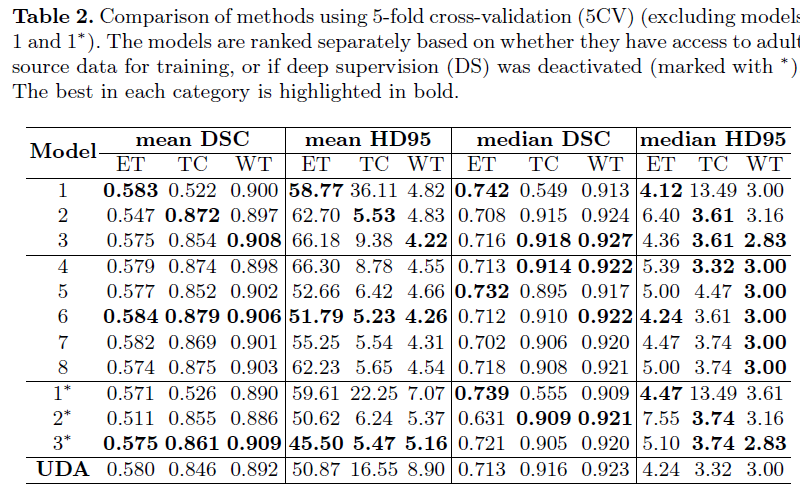

Conclusion
This evaluation aimed to compare the nnU-Net baseline model’s segmentation performance on the BraTS-PEDs 2023 dataset with results reported in the original paper. We calculated the Dice coefficient and Hausdorff distance (HD95) for the three key tumor regions: Whole Tumor (WT), Tumor Core (TC), and Enhancing Tumor (ET).

Key Findings:

The nnU-Net baseline achieved a mean Dice score of 0.887 (WT), 0.440 (TC), and 0.541 (ET).

The corresponding median Dice scores were 0.907 (WT), 0.509 (TC), and 0.726 (ET), which are comparable to the reported values in the paper, especially for WT and ET.

However, the model exhibited higher Hausdorff distances than those reported in the paper, especially for WT and TC regions. This indicates that while the model performs reasonably well in segmenting the tumor regions, its segmentation boundaries are less accurate and may be noisy.

Conclusion:
The nnU-Net baseline model shows acceptable performance on the BraTS-PEDs 2023 dataset, particularly in terms of Dice scores. Although there are discrepancies in Hausdorff distances compared to the reference paper, the overall segmentation quality is sufficient to consider this model as a baseline. This evaluation validates the model’s inference pipeline and provides a reliable foundation for future experiments involving pruning, fine-tuning, and post-processing aimed at improving segmentation performance.